# <전반부 실습>
# ⏰ 시계열 데이터 분석 실습 (**코랩에서 실행!!**)

> **시계열 데이터**: 시간의 흐름에 따라 관측되어 수집된 통계량으로 시간의 영향을 받는 데이터

**학습 목표:**
1. 시계열 데이터의 기본 개념과 특징 이해
2. 시계열 데이터 전처리 방법 학습 (결측치/이상치, 요소분해)
3. 정상성 개념 및 검정 방법 이해
4. 정상성 확보를 위한 변환 기법 실습

## 0. 환경 설정

In [1]:
# 1. 코랩용 한글 폰트 설치 (설치 후 출력창이 지저분하지 않게 조용히 설치)
!pip install -q koreanize-matplotlib
import koreanize_matplotlib

# 2. 기본 데이터 처리 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 3. 시계열 분석 및 모델링 라이브러리 모음
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

print("✅ 환경 설정 및 라이브러리 로드 완료")


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ 환경 설정 및 라이브러리 로드 완료


---

# Part 1. 시계열 데이터 기본 개념

## 1.1 시계열 데이터의 특징

- **시간의존성 (Temporal Dependence)**: 데이터는 시간에 따라 변화한다
- **자기상관성 (Autocorrelation)**: 이전 시점의 값이 이후 시점의 값에 영향을 미친다
- **계절성 (Seasonality) & 추세 (Trend)**: 시간에 따라 장기적으로 증가/감소하는 추세 + 일정 주기로 반복되는 패턴

## 1.2 Sunspots 데이터 소개

### Sunspots Yearly Dataset (태양 흑점 연간 관측 데이터)

- 태양의 표면에서 관측되는 "흑점(Sunspots)"의 개수를 1년 단위로 기록한 데이터
- **관측 시작**: 1700년
- **종료**: 2008년
- **빈도**: Annual (연간)
- **값**: 그 해에 관측된 태양 흑점의 평균 개수
- **특징**: 태양 흑점은 약 **11년 주기**로 증가·감소하는 경향

## 1.3 데이터 로드 및 기본 시각화

pd.to_datetime() 함수 사용법:
- 기본 형식: pd.to_datetime(데이터, format='날짜형식')
- format 파라미터:  
· '%Y': 4자리 연도 (예: 2023)
· '%y': 2자리 연도 (예: 23)
· '%m': 월 (01-12)
· '%d': 일 (01-31)
· '%H': 시간 (00-23)
· '%M': 분 (00-59)

In [ ]:
# Sunspots 연간 데이터 불러오기 (statsmodels 내장 데이터)
data = sm.datasets.sunspots.load_pandas().data

# 'YEAR' → datetime 변환
# pd.to_datetime(데이터, format='날짜형식'), 4자리 연도 방식을 사용해주세요!
data['YEAR'] = pd.to_datetime(data['YEAR'].astype(int).astype(str), format='**')

# 시계열 분석에서는 날짜를 인덱스로 설정해야 함
# inplace=True는 원본 데이터를 직접 수정
data.set_index('YEAR', inplace=True)

print(f"데이터 shape: {data.shape}")
print(f"\n데이터 기간: {data.index[0].year} ~ {data.index[-1].year}")

print(f"\n기본 통계:")
print(data['SUNACTIVITY'].describe())

데이터 shape: (309, 1)

데이터 기간: 1700 ~ 2008

기본 통계:
count    309.000000
mean      49.752104
std       40.452595
min        0.000000
25%       16.000000
50%       40.000000
75%       69.800000
max      190.200000
Name: SUNACTIVITY, dtype: float64


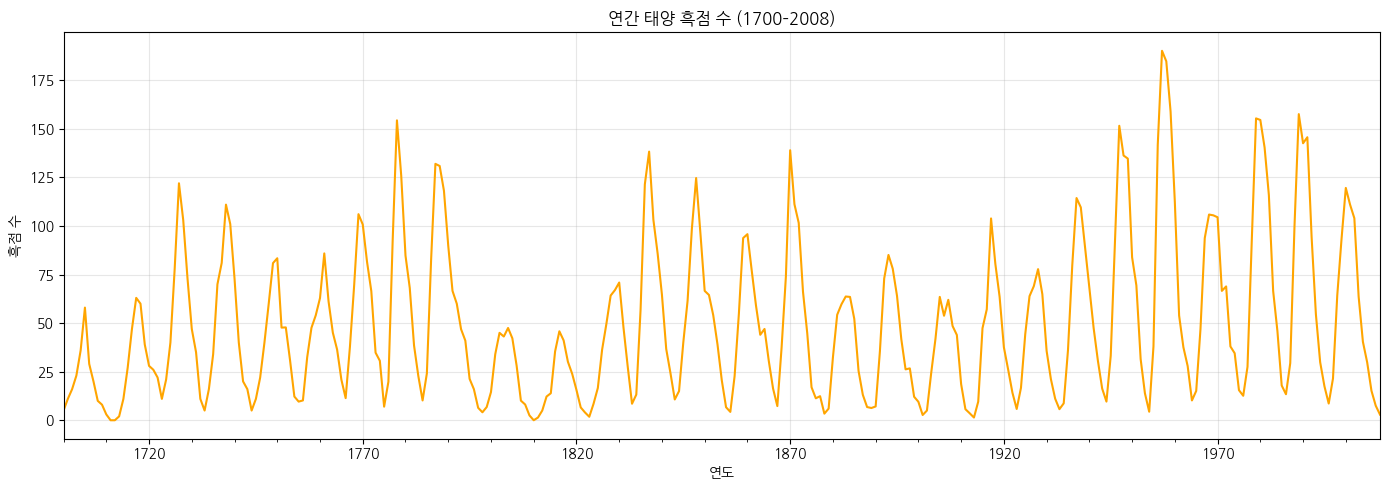

In [3]:
# 시각화

plt.figure(figsize=(14, 5))
data['SUNACTIVITY'].plot(title='연간 태양 흑점 수 (1700–2008)', color='orange', linewidth=1.5)
plt.ylabel('흑점 수')
plt.xlabel('연도')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 관찰 포인트

1. **주기성**: 약 11년마다 흑점 수가 증가와 감소를 반복 (태양 활동 주기)   
    단, 주기 길이와 peak 높이가 매번 조금씩 다름
2. **추세**: 전반적으로 1700년대보다 1900년대 후반의 평균 흑점 수가 높음
3. **변동성**: Peak 값의 크기가 주기마다 다름 (최대 190개, 최소 0개 근처)

---

# Part 2. 시계열 요소 분해 (Decomposition)

> **요소분해**: 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해하는 과정

태양 흑점 수는 약 **11년 주기**가 있기 때문에 요소 분해 시 `period=11`을 사용합니다.

태양 흑점 주기💡
- 엄밀히는 흑점 주기가 9~14년으로 매번 조금씩 변동하기 때문에 고정 주기의 **계절성**보다 **순환성(Cycle)**에 가깝습니다.
- 다만, 평균적으로 약 11년으로 규칙적이고 주기 값을 알고 있으므로, period=11로 계절성에 준하여 처리하도록 하겠습니다.

**seasonal_decompose() 함수 사용법:**
- `model='additive'`: 가법 모형 (데이터 = 추세 + 계절성 + 잔차)
- `model='multiplicative'`: 승법 모형 (데이터 = 추세 × 계절성 × 잔차)
- `period`: 계절성 주기

**언제 어떤 모형을 사용할까?**
- 가법 모형: 계절성 변동폭이 일정할 때
- 승법 모형: 추세가 증가하면 계절성 변동폭도 커질 때

## 2.1 가법 모형 (Additive Model)

가법 모형은 시계열을 다음과 같이 분해합니다:

$$Y_t = T_t + S_t + E_t$$

- $T_t$: 추세 (Trend)
- $S_t$: 계절성 (Seasonal)
- $E_t$: 잔차 (Residual/Error)

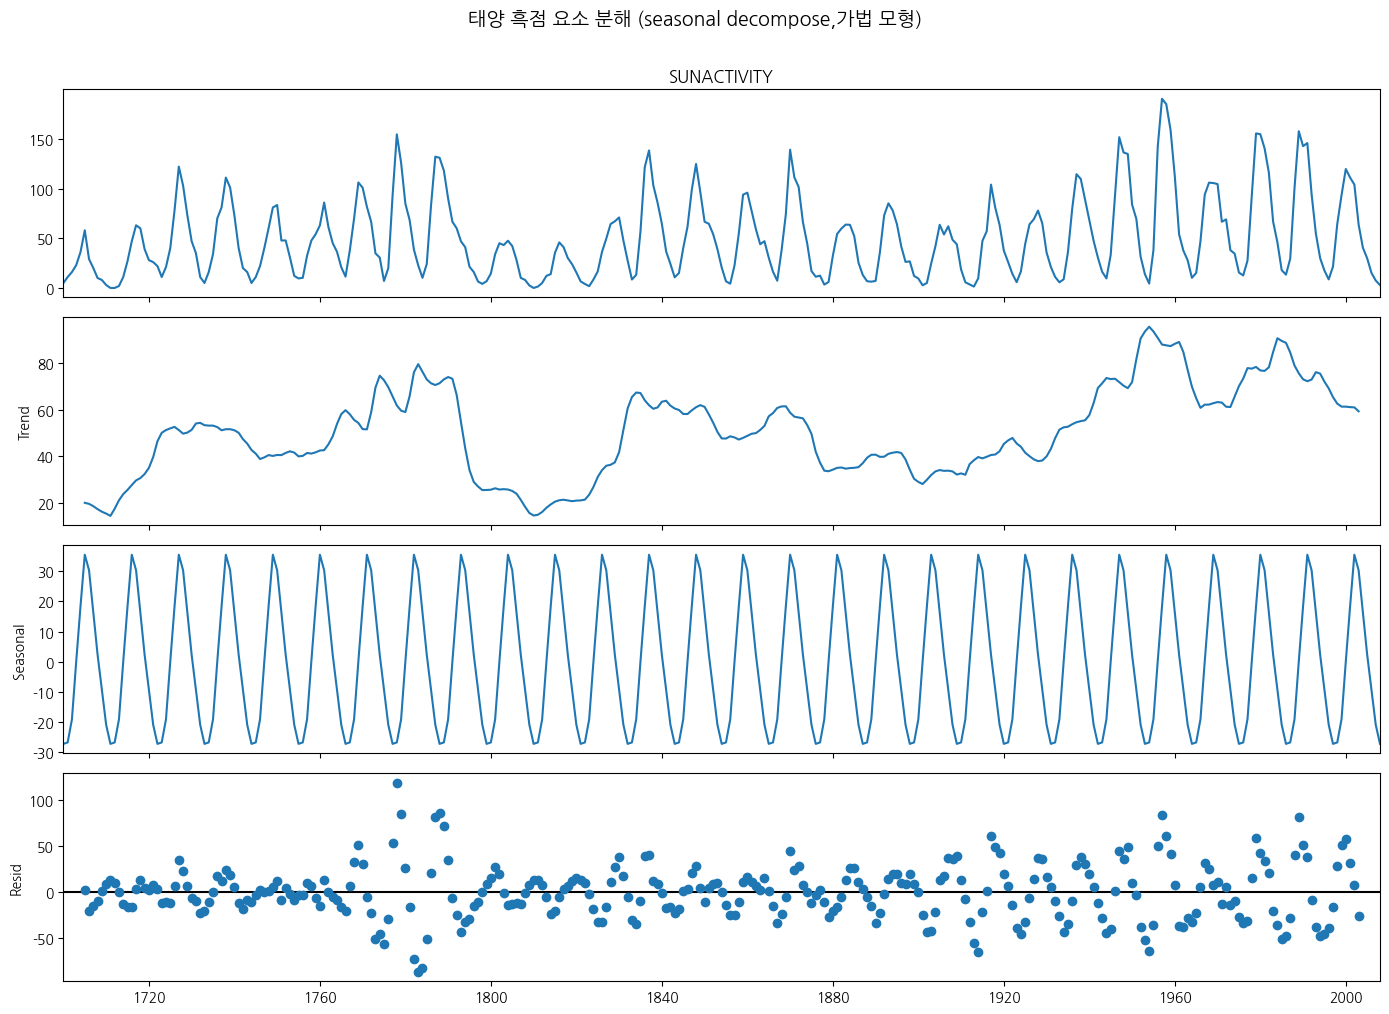

In [ ]:
# 가법 모형으로 요소 분해
decomp_add = seasonal_decompose(
    data['SUNACTIVITY'],
    model='********', # 어떤 모형일까요
    period=** # 주기가 뭐죠
)

# 시각화
fig_add = decomp_add.plot()
fig_add.set_size_inches(14, 10)
plt.suptitle("태양 흑점 요소 분해 (seasonal decompose,가법 모형)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 2.2 승법 모형 (Multiplicative Model)
### 2.2.1 개념
승법 모형은 시계열을 다음과 같이 분해합니다:

$$Y_t = T_t \times S_t \times E_t$$

**주의**: 승법 모형은 시계열 값이 **0 또는 음수**면 적용할 수 없습니다.

In [ ]:
try:
    decomp_mul_raw = seasonal_decompose(
        data['SUNACTIVITY'],
        model='**************', # 어떤 모형일까요
        period=** # 주기가 뭐죠
    )
    print("✅ 승법 모형 적용 성공!")
except Exception as e:
    print("❌ 오류 발생!")
    print(f"오류 타입: {type(e).__name__}")
    print(f"오류 메시지: {str(e)}")

❌ 오류 발생!
오류 타입: ValueError
오류 메시지: Multiplicative seasonality is not appropriate for zero and negative values


### 2.2.2 0 또는 음수 값 확인

오류 메시지: Multiplicative seasonality is not appropriate for zero and negative values

승법 모형은 $Y_t = T_t \times S_t \times E_t$ 형태로 분해하므로, **0이나 음수가 있으면 수학적으로 불가능**합니다.

데이터에 0 또는 음수 값이 있는지 확인해보겠습니다.

전체 데이터 개수: 309개
0 이하 값 개수: 3개
0 이하 값 비율: 0.97%

0 이하 값이 있는 연도 (처음 10개):
            SUNACTIVITY
YEAR                   
1711-01-01          0.0
1712-01-01          0.0
1810-01-01          0.0


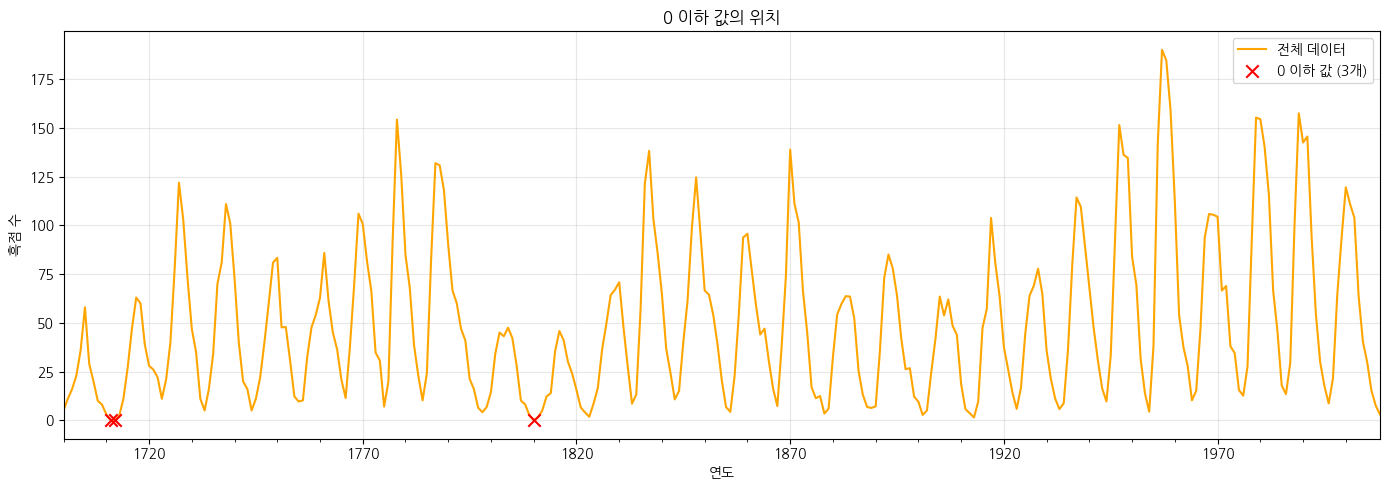

In [6]:
# 0 또는 음수 값 확인
zero_or_negative = data[data['SUNACTIVITY'] <= 0]

print(f"전체 데이터 개수: {len(data)}개")
print(f"0 이하 값 개수: {len(zero_or_negative)}개")
print(f"0 이하 값 비율: {len(zero_or_negative)/len(data)*100:.2f}%")

if len(zero_or_negative) > 0:
    print(f"\n0 이하 값이 있는 연도 (처음 10개):")
    print(zero_or_negative.head(10))

    # 시각화
    plt.figure(figsize=(14, 5))
    data['SUNACTIVITY'].plot(color='orange', linewidth=1.5, label='전체 데이터')
    plt.scatter(zero_or_negative.index, zero_or_negative['SUNACTIVITY'],
                color='red', s=80, zorder=5, label=f'0 이하 값 ({len(zero_or_negative)}개)', marker='x')
    plt.ylabel('흑점 수')
    plt.xlabel('연도')
    plt.title('0 이하 값의 위치')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### 2.2.3 해결 방법: 양수 값만 필터링

그래프를 확인해보시면, 0 이하 값이 존재함을 알 수 있습니다.

**결론:** 승법 모형을 적용하려면 **0보다 큰 값만 선택**해야 합니다.

이제 0보다 큰 값만 필터링하여 승법 모형을 적용하겠습니다.

In [7]:
# 0보다 큰 값만 필터링
data_pos = data[data['SUNACTIVITY'] > 0].copy()

print(f"원본 데이터 개수: {len(data)}개")
print(f"양수 데이터 개수: {len(data_pos)}개")
print(f"제거된 0 값 개수: {len(data) - len(data_pos)}개")

원본 데이터 개수: 309개
양수 데이터 개수: 306개
제거된 0 값 개수: 3개


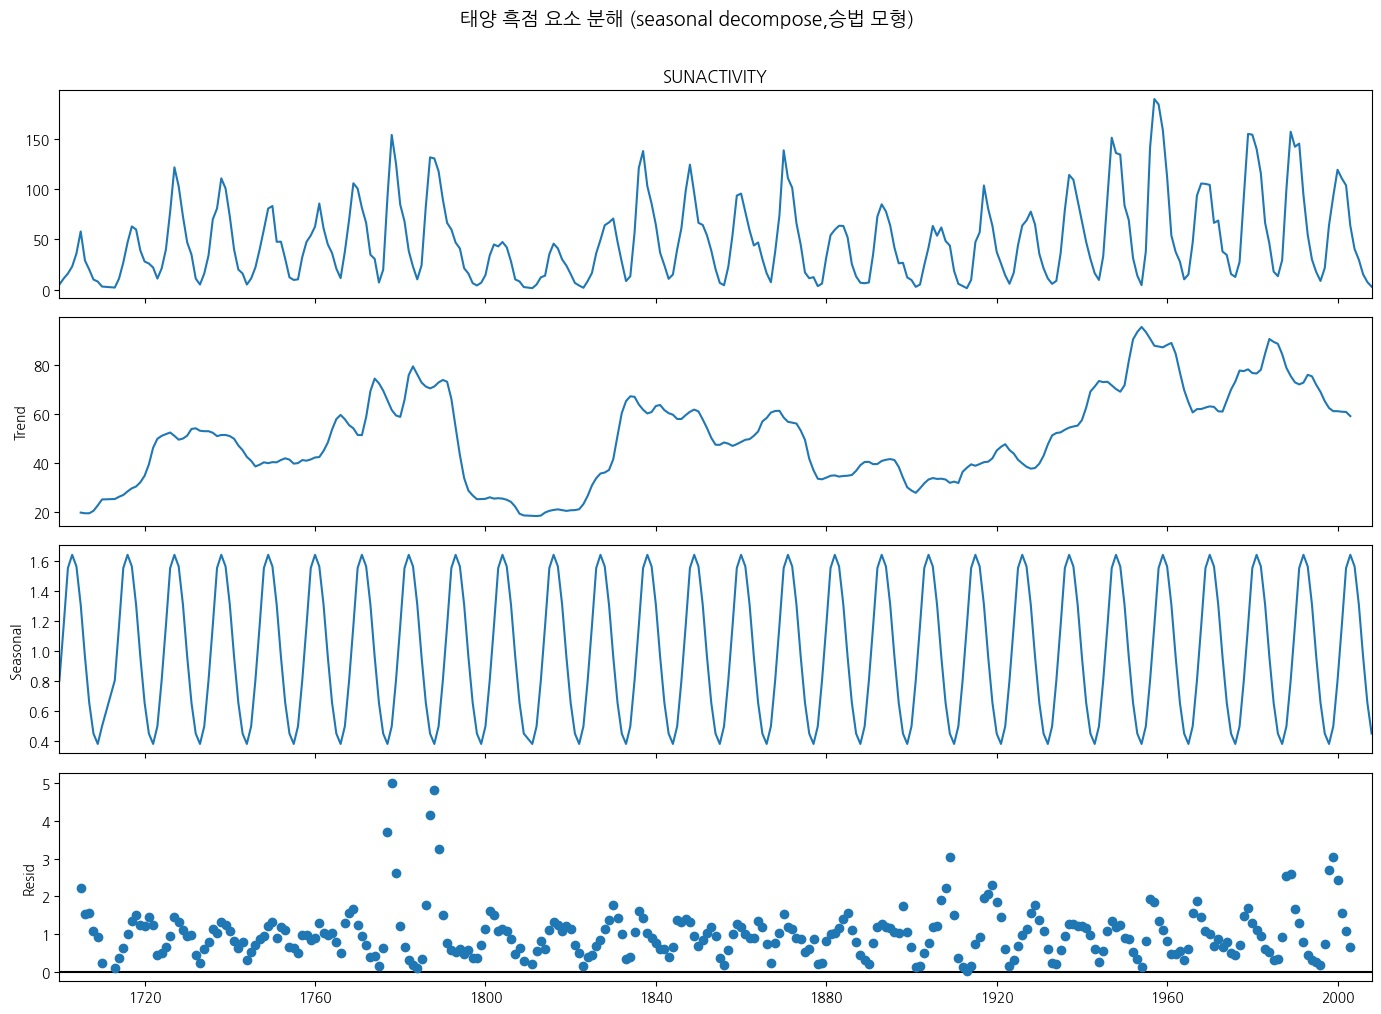

In [ ]:
# 승법 모형으로 요소 분해
# 힌트: 시계열 분해 함수
decomp_mul = ********_*********(
    data_pos['SUNACTIVITY'],
    # 힌트: 승법 모형 (multiplicative)
    model='**************',
    # 힌트: 주기
    period=**
)

# 시각화
fig_mul = decomp_mul.plot()
fig_mul.set_size_inches(14, 10)
plt.suptitle("태양 흑점 요소 분해 (seasonal decompose,승법 모형)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 가법 vs 승법

In [9]:
# 가법 vs 승법 잔차 비교 (원래 단위 기준)
resid_add = decomp_add.resid.dropna()

# 승법 잔차를 원래 단위(흑점 개수)로 환산
# 승법: Y = T × S × R  →  오차 = T × (R - 1)
resid_mul_original = (decomp_mul.trend * (decomp_mul.resid - 1)).dropna()

# 공통 구간만 비교
common = resid_add.index.intersection(resid_mul_original.index)
rmse_add = np.sqrt((resid_add.loc[common]**2).mean())
rmse_mul = np.sqrt((resid_mul_original.loc[common]**2).mean())

print(f'가법 잔차 RMSE: {rmse_add:.2f}')
print(f'승법 잔차 RMSE: {rmse_mul:.2f}')

가법 잔차 RMSE: 29.73
승법 잔차 RMSE: 41.38


- RMSE가 낮음 => 요소 분해 후 남은 잔차가 더 작음
- 태양 흑점 데이터에서는 **가법 요소분해**가 원본 시계열의 변동을 더 잘 설명한다고 볼 수 있음
- 이유는?
    - 태양 흑점 데이터는 추세가 높아져도 계절 진폭이 비례해서 커지지 않아 승법 모형의 전제 조건에 맞지 않음
    - 흑점 수는 극소기에는 0에 가까운 값을 보이는 경우가 있어, 승법모형의 비율 기반 분해 과정에서 잔차가 상대적으로 불안정해질 수 있음

## 참고) STL vs Seasonal Decompose  
요소분해 하는 방법으로 seasonal decompose 말고 STL도 있었죠?   

| 구분 | STL | Seasonal Decompose |
|------|------|---------------------|
| 요소 분해 방식 | LOESS(국소 회귀) | 이동평균 기반 고전적 분해 |
| 계절성 처리 | **시간에 따라 변하는 계절성 반영** | **고정된 계절성만 반영** |
| 이상치 영향 | 적게 받음 (robust 옵션 가능) | 많이 받음 |
| 데이터 손실 | 없음 | 있음 (이동평균 계산 구간만큼 앞뒤 데이터 손실) |

**STL**은 LOESS 기반으로 계절성과 추세를 국소적으로 반복 추정하기 때문에   
계절성의 진폭이나 형태가 시간이 흐르면서 변하는 실제 데이터 환경을 자연스럽게 반영할 수 있어요.   
반면 **Seasonal Decompose**는 고정된 계절 패턴을 전제로 하므로, 계절성이 변하거나 이상치가 포함된 데이터에서는 분해 성능이 떨어질 수 있습니다!

태양 흑점 데이터를 STL로도 요소분해 해보고 seasonal decompose랑 비교해보도록 하겠습니다.

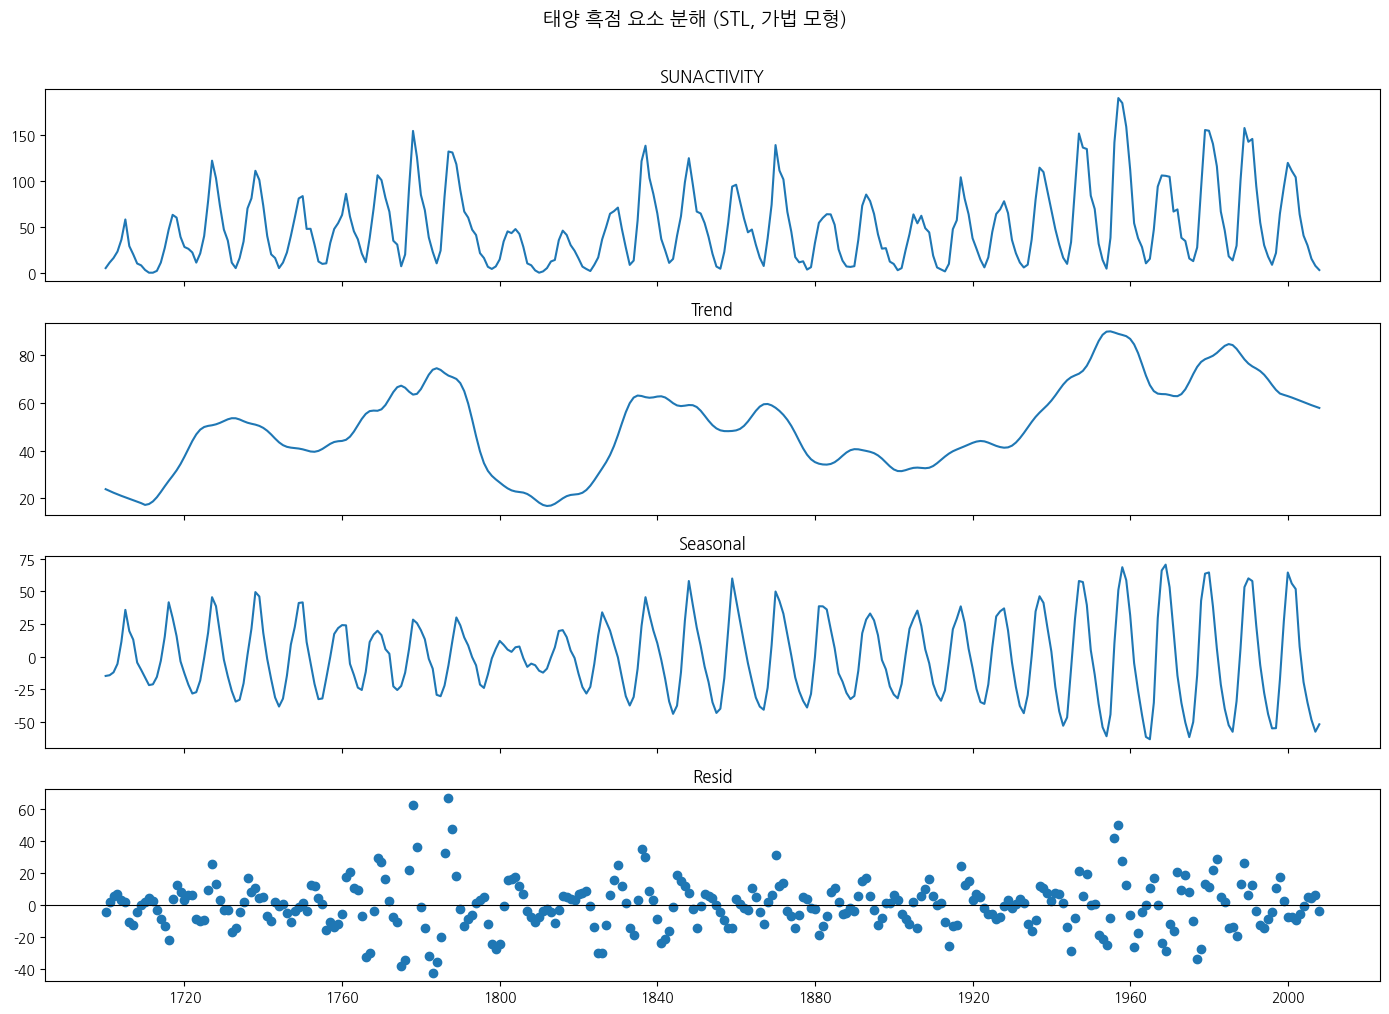

In [154]:
from statsmodels.tsa.seasonal import STL

# STL 가법 모형으로 요소 분해
stl = STL(
    data['SUNACTIVITY'],
    period=11   # 태양 흑점 주기(대략 11년 주기)
)
result = stl.fit()

# 시각화
# STL은 내장 plot에 figsize 옵션이 없어서, figure와 axes를 따로 만들어 크기를 조절해야 합니다
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(result.observed)
axes[0].set_title("SUNACTIVITY")

axes[1].plot(result.trend)
axes[1].set_title("Trend")

axes[2].plot(result.seasonal)
axes[2].set_title("Seasonal")

axes[3].plot(result.resid, marker='o', linestyle='none')
axes[3].axhline(0, color='black', linewidth=0.8)
axes[3].set_title("Resid")

fig.suptitle("태양 흑점 요소 분해 (STL, 가법 모형)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**Seasonal Decompose 가법모형 결과 이미지**
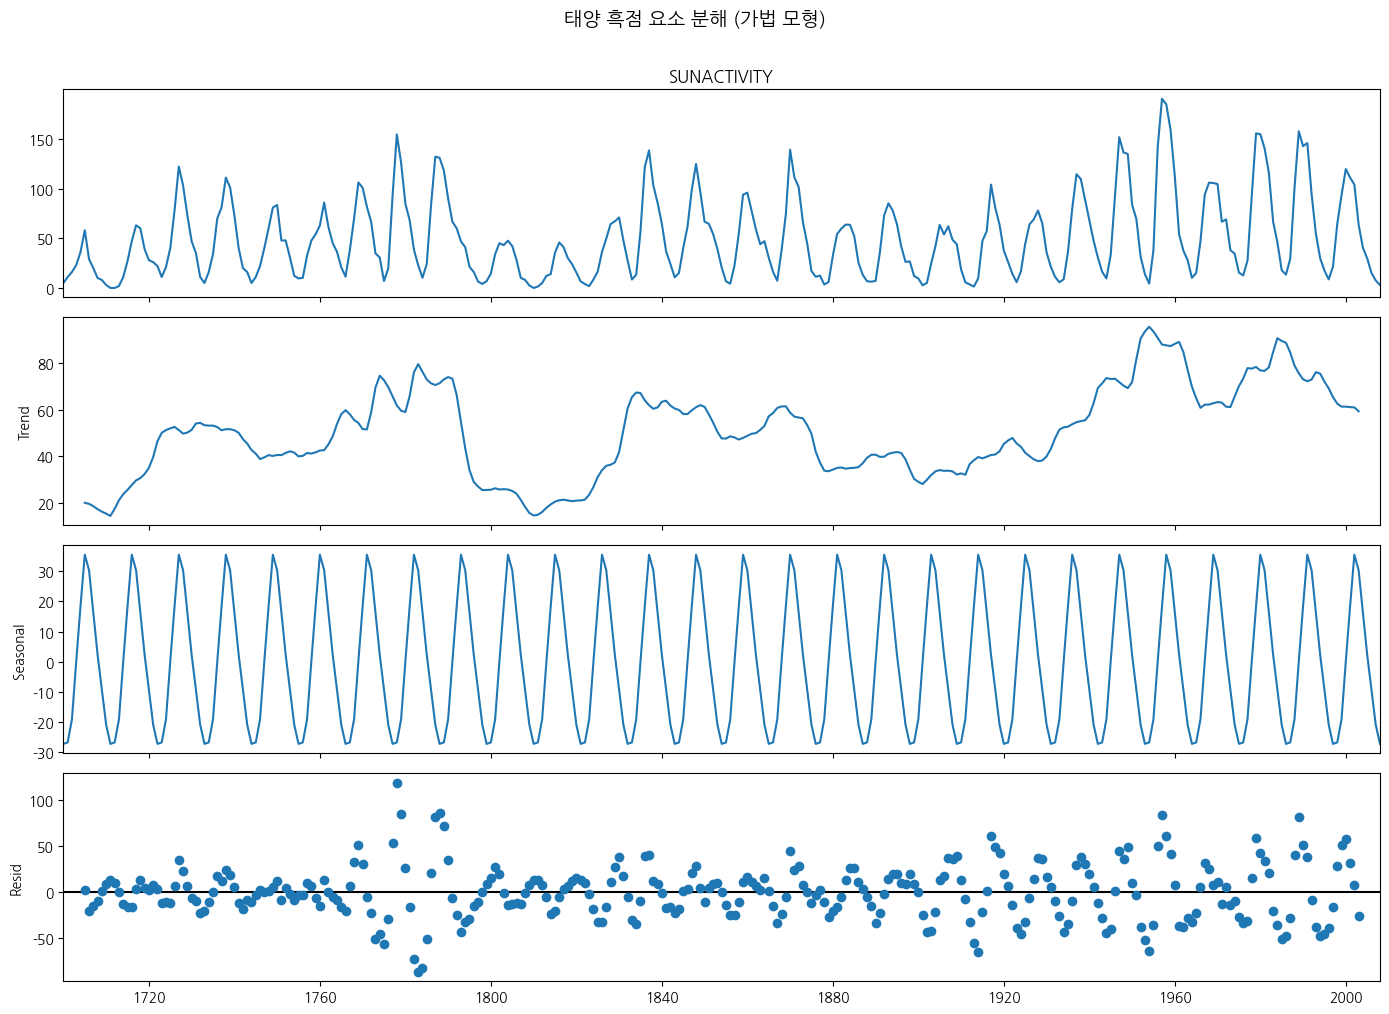


seasonal decompose는 Trend에 계절성이 완전히 분리되지 않은 잔여 진동이 남아있고, Seasonal이 시간에 따라 일정합니다.  
반면 STL은 Trend가 더 매끄럽고, Seasonal이 시간에 따라 변하는 패턴을 반영합니다.
흑점 데이터는 주기마다 진폭이 다르므로 **변동하는 계절성을 반영하는 STL**이 더 적합한 분해 방법입니다. 

## 2.3 요소 분해 결과 해석 

| 구성요소 | 특징 | 해석 |
|---------|-------|--------|
| **원본 시계열 (SUNACTIVITY)** | - 약 11년 주기 반복<br>- Peak: 150~190<br>- Valley: 0 근처 | → 태양 흑점의 **주기성 + 장기적 변동**이 동시에 존재 |
| **추세 (Trend)** | - 1700년대 초반: 낮음<br>- 1780~1820: 급락 (달튼 최소기)<br>- 1870~1960: 상승 추세<br>- 1960~2000: 높은 수준 유지 | → **장기적 증가 경향**, 역사적 최소·최대기 반영 |
| **계절성 (Seasonal)** | - 약 11년 주기 반복<br> - 모양은 대체로 규칙적 (사인파 비슷)<br> - 진폭은 시기별로 다를 수 있음 (STL에서 더 잘 드러남) | → 흑점의 **11년 주기성**을 보여줌 |
| **잔차 (Residual)** | - 평균 0 근처에서 흩어짐<br>- 1780~1830 변동 폭 큼<br>- 구조적 패턴 없음 | → **추세·계절성으로 설명되지 않는 불규칙 변동(노이즈)** |

**종합 해석:**

태양 흑점 데이터는 **약 11년 주기의 반복적 변동**, **장기간의 추세 변화**, 그리고 예측하기 어려운 **불규칙 변동**(잔차)으로 구성됩니다.

---

# Part 3. 전처리 - 결측치 처리

## 3.1 결측치 확인

In [10]:
# 결측치 확인
print("결측치 개수:")
print(data.isnull().sum())

print(f"\n결측치 비율: {data['SUNACTIVITY'].isnull().sum() / len(data) * 100:.2f}%")

결측치 개수:
SUNACTIVITY    0
dtype: int64

결측치 비율: 0.00%


**결과:** 실제 데이터에는 결측치가 없습니다.

하지만 **보간 방법** 실습을 위해 인위적으로 결측치를 생성해보겠습니다.

## 3.2 결측치 생성 및 보간 실습

### 3.2.1 인위적 결측치 생성

실습을 위해 **1800-1900년 구간(100년)에 35개의 결측치**를 생성합니다.

**이 구간을 선택한 이유:**
- 태양 흑점의 11년 주기가 약 9번 반복되어 보간 방법의 패턴 추적 능력을 평가하기 용이
- 충분한 결측치(~35%)로 각 보간 방법의 특징을 극대화
- 시각화 시 비교가 명확함

In [11]:
# 1. 원본 데이터 복사
data_with_missing = data['SUNACTIVITY'].copy()

# 2. 1800-1900년 구간에서 결측치 생성
# seed 함수를 통해 재현 가능하도록 설정할 수 있습니다
np.random.seed(42)  # 재현 가능하도록

# 1800-1900년 구간의 인덱스 추출
range_data = data.loc['1800':'1900']
n_missing = 35  # 해당 구간에 35개의 결측치 생성

missing_indices = np.random.choice(
    range_data.index,
    size=n_missing,
    replace=False
)

# 결측치로 변환
data_with_missing.loc[missing_indices] = np.nan

print(f"생성된 결측치 개수: {n_missing}개")
print(f"결측치 생성 구간: 1800-1900년")
print(f"해당 구간 전체 데이터: {len(range_data)}개")
print(f"해당 구간 결측치 비율: {n_missing/len(range_data)*100:.1f}%")
print(f"\n결측치가 생성된 연도 (처음 10개):")
print(sorted(missing_indices)[:10])

생성된 결측치 개수: 35개
결측치 생성 구간: 1800-1900년
해당 구간 전체 데이터: 101개
해당 구간 결측치 비율: 34.7%

결측치가 생성된 연도 (처음 10개):
[np.datetime64('1800-01-01T00:00:00.000000000'), np.datetime64('1804-01-01T00:00:00.000000000'), np.datetime64('1809-01-01T00:00:00.000000000'), np.datetime64('1810-01-01T00:00:00.000000000'), np.datetime64('1811-01-01T00:00:00.000000000'), np.datetime64('1812-01-01T00:00:00.000000000'), np.datetime64('1815-01-01T00:00:00.000000000'), np.datetime64('1818-01-01T00:00:00.000000000'), np.datetime64('1822-01-01T00:00:00.000000000'), np.datetime64('1826-01-01T00:00:00.000000000')]


### 3.2.2 결측치 보간 (Interpolation) 적용: Spline 보간법

시계열 데이터의 결측치를 채우는 방법에는 여러 가지가 있습니다.
1. **Linear (선형 보간):** 결측치 전후를 '직선'으로 연결
2. **Forward/Backward Fill:** 결측치를 이전(또는 다음) 값으로 그대로 채움 (계단 현상 발생)
3. **Spline (스플라인 보간):** 여러 점을 '부드러운 곡선'으로 연결

태양 흑점 데이터는 약 11년 주기의 곡선 패턴을 가지므로, 데이터 포인트 사이를 부드러운 곡선으로 연결하는 **Spline 보간법**을 실습해보도록 하겠습니다.

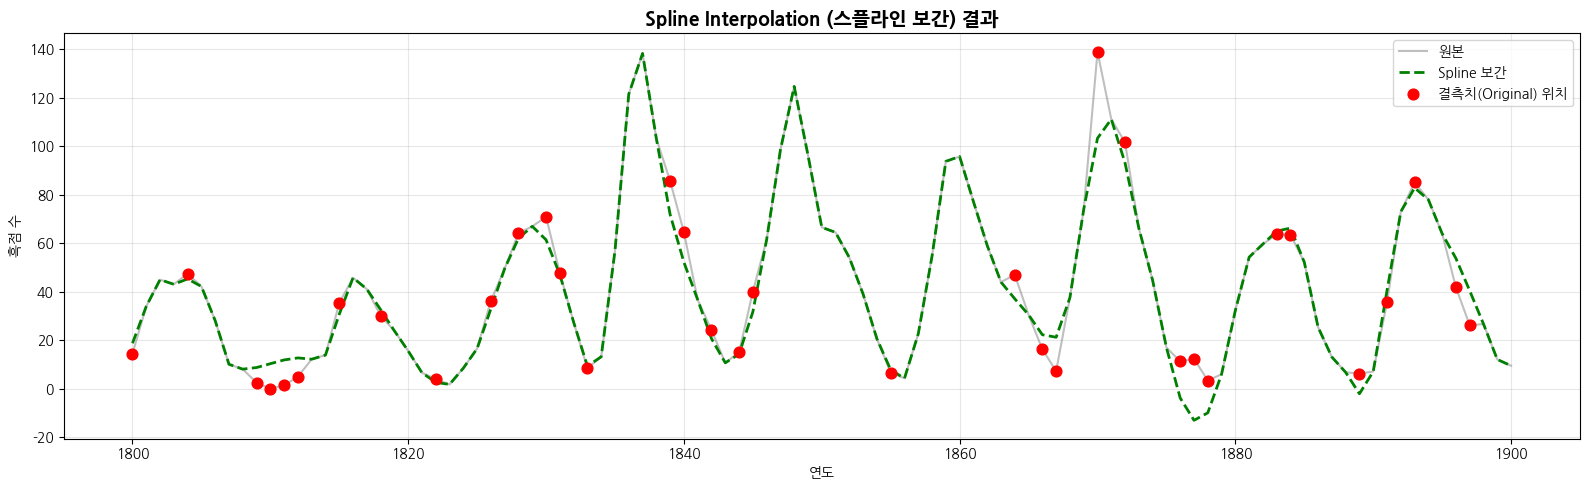

✅ Spline 보간 완료
   남은 결측치: 0개


In [ ]:
# Spline 보간 적용 (3차 스플라인)
# 힌트: 보간 메서드, method='spline', order=3
data_spline = data_with_missing.interpolate(method='******', order=*)

# 시각화
plt.figure(figsize=(16, 5))

# 해당 구간의 결측치만 필터링 (1800년대 확대한 모습)
missing_in_range = [idx for idx in missing_indices if '1800-01-01' <= str(idx) <= '1900-01-01']

# 원본 데이터 (회색)
plt.plot(data['SUNACTIVITY'].loc['1800-01-01':'1900-01-01'],
         label='원본', color='gray', linewidth=1.5, alpha=0.5)

# Spline 보간 결과 (초록색)
plt.plot(data_spline.loc['1800-01-01':'1900-01-01'],
         label='Spline 보간', color='green', linewidth=2, linestyle='--')

# 결측치 위치 (빨간 점)
if missing_in_range:
    plt.scatter(missing_in_range, data['SUNACTIVITY'].loc[missing_in_range],
                color='red', s=60, zorder=5, label='결측치(Original) 위치')

plt.title('Spline Interpolation (스플라인 보간) 결과', fontsize=14, fontweight='bold')
plt.xlabel('연도')
plt.ylabel('흑점 수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ Spline 보간 완료")
print(f"   남은 결측치: {data_spline.isna().sum()}개")

그래프를 보면 결측치(빨간 점) 구간이 부자연스러운 직선이나 계단 형태가 아니라, 기존 데이터의 흐름을 따라 아주 자연스러운 곡선 형태로 복원된 것을 확인할 수 있습니다.

이제 성공적으로 결측치가 채워진 이 데이터(`data_spline`)를 바탕으로, 이상치 탐지를 진행해보겠습니다.

# Part 4. 전처리 - 이상치 탐지

데이터를 모델에 넣기 전에, 비정상적으로 튀는 값(이상치)이 없는지 확인해야 합니다. 시계열 데이터에서 이상치를 탐지하는 방법은 크게 두 가지가 있습니다.

1.  **Z-score 방식:** 평균에서 표준편차의 3배(|Z| > 3) 이상 벗어난 값을 찾습니다. (단, 평균 자체가 이상치에 영향을 받아 왜곡될 수 있음)
2.  **IQR 방식:** 사분위수를 이용해 Q1과 Q3를 기준으로 1.5*IQR 범위를 벗어난 값을 찾습니다. (데이터 분포 형태에 덜 민감하고 직관적이라 실무에서 자주 씁니다.)

이번 실습에서는 보다 직관적이고 안정적인 **IQR 기반 방식**으로 태양 흑점 데이터의 이상치를 탐지해 보겠습니다.

## 4.1 IQR 기반 이상치 탐지 및 평가

In [13]:
# IQR 기반 이상치 탐지
# 힌트: 25% 백분위수(Q1), 75% 백분위수(Q3) 계산
Q1 = data['SUNACTIVITY'].quantile(0.25)
Q3 = data['SUNACTIVITY'].quantile(0.75)
IQR = Q3 - Q1

# IQR 기준 설정
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 탐지 (하한보다 작거나 상한보다 큰 값)
outliers_iqr = data[(data['SUNACTIVITY'] < lower) | (data['SUNACTIVITY'] > upper)]

print(f"정상 범위: [{lower:.2f}, {upper:.2f}]")
print(f"IQR 기준 이상치 개수: {len(outliers_iqr)}개")
print(f"\n상위 5개 이상치:")
print(outliers_iqr.head())

정상 범위: [-64.70, 150.50]
IQR 기준 이상치 개수: 8개

상위 5개 이상치:
            SUNACTIVITY
YEAR                   
1778-01-01        154.4
1947-01-01        151.6
1957-01-01        190.2
1958-01-01        184.8
1959-01-01        159.0


## 4.2 발견된 이상치, 어떻게 해야 할까요?

### ❓ 통계적으로 이상치 판정을 받았으니 무조건 제거해야 할까?
**정답은 NO!**

출력된 이상치들을 보면 대부분 150~190대의 아주 큰 값들입니다. 하지만 천문학 도메인 지식을 바탕으로 보면, 이는 단순히 에러가 아니라 **태양 활동 11년 주기의 Peak(극대기)**에 해당하는 정상적이고 중요한 데이터입니다.

### 💡 결론
이러한 정상적인 패턴을 단순 통계 기준(IQR)으로 지워버리면 시계열 모델이 가장 중요한 극대기 정보를 학습하지 못하게 됩니다.
**따라서, 이 데이터에서는 이상치를 제거하지 않고 원본 그대로 사용하는 것이 올바른 방향입니다.**

*(※ 참고: 만약 이런 정상적인 Peak 때문에 단순 IQR 방식에 false outlier(오탐)가 너무 많이 뜬다면, 앞서 배운 '요소분해'를 통해 추세와 계절성을 걷어낸 **'순수한 잔차(Residual)'에만 IQR을 적용**하여 찐 이상치를 찾는 방법도 실무에서 자주 사용됩니다. 본 데이터는 일부 구간에서 잔차가 크게 튀는 값이 존재하여, 해당 방법 적용 시 추가적인 도메인 해석이 필요하므로 본 실습에서는 생략합니다.)*

---

# Part 5. 정상성 검정

시계열 모델을 사용하기 위해서는 시계열 데이터의 **정상성(Stationarity)**을 확보해야 합니다.

**정상성이란?**
- 평균이 시간에 따라 일정
- 분산이 시간에 따라 일정
- 공분산이 시차에만 의존

## 5.1 ADF Test (Augmented Dickey-Fuller Test)

**귀무가설 (H0)**: 시계열 데이터는 **비정상** (단위근 존재)  
**대립가설 (H1)**: 시계열 데이터는 **정상**

- p-value < 0.05: 정상 시계열
- p-value ≥ 0.05: 비정상 시계열

In [ ]:
# ADF 검정 함수 정의
def adfuller_test(series, **kw):
    # 힌트: ADF 검정 함수 (statsmodels.tsa.stattools의 adfuller)
    adf, p_value, nlags, number_of_observations, critical_values, _ = ********(series, **kw)

    print(f'ADF Statistic: {adf:.5f}')
    print(f'p-value: {p_value:.4f}')
    print(f'Lags: {nlags}')
    print(f'Number of Observations: {number_of_observations}')
    # 힌트: p-value가 0.05보다 크면 비정상
    print(f'검증결과: {"비정상(non-stationary)" if p_value >= **** else "정상(stationary)"} 시계열 데이터입니다.')

    # 힌트: p-value < 0.05이면 정상
    return p_value < ****

# 원본 데이터에 대한 ADF 검정
print("="*50)
print("원본 데이터 ADF 검정")
print("="*50)
is_stationary_adf = adfuller_test(data['SUNACTIVITY'])

원본 데이터 ADF 검정
ADF Statistic: -2.83778
p-value: 0.0531
Lags: 8
Number of Observations: 300
검증결과: 비정상(non-stationary) 시계열 데이터입니다.


## 5.2 KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin Test)

**귀무가설 (H0)**: 시계열 데이터는 **정상**  
**대립가설 (H1)**: 시계열 데이터는 **비정상** (단위근 존재)

**KPSS 검정:**
- ADF와 반대 방향의 검정 (귀무가설: 정상 시계열)
- p-value ≤ 0.05: 비정상 시계열
- p-value > 0.05: 정상 시계열
- ADF와 함께 사용하여 더 확실한 판단

In [ ]:
# KPSS 검정 함수 정의
def kpss_test(series, **kw):
    # 힌트: KPSS 검정 함수 (statsmodels.tsa.stattools의 kpss)
    stats, p_value, nlags, critical_values = ****(series, **kw)

    print(f'KPSS Statistic: {stats:.5f}')
    print(f'p-value: {p_value:.4f}')
    print(f'Lags: {nlags}')
    # 힌트: p-value가 0.05 이하면 비정상 (ADF와 반대)
    print(f'검증결과: {"비정상(non-stationary)" if p_value < **** else "정상(stationary)"} 시계열 데이터입니다.')

    # 힌트: p-value > 0.05이면 정상
    return p_value > ****

# 원본 데이터에 대한 KPSS 검정
print("="*50)
print("원본 데이터 KPSS 검정")
print("="*50)
is_stationary_kpss = kpss_test(data['SUNACTIVITY'])

원본 데이터 KPSS 검정
KPSS Statistic: 0.66987
p-value: 0.0163
Lags: 7
검증결과: 비정상(non-stationary) 시계열 데이터입니다.


---

# Part 6. 차분 (Differencing)을 통한 정상성 확보

앞서 ADF/KPSS 검정을 통해 원본 데이터가 **비정상 시계열**임을 확인했습니다.

이제 **차분(Differencing)**을 통해 정상성을 확보하겠습니다.

## 6.1 1차 차분 (First-order Differencing)

1차 차분은 현재 시점과 이전 시점의 차이를 계산합니다:

$$\nabla Y_t = Y_t - Y_{t-1}$$


- 현재 값 - 이전 값
- 추세를 제거하여 평균을 일정하게 만듦
- diff(): 차분 계산
- dropna(): 첫 번째 값은 결측치가 되므로 제거

원본 데이터 개수: 309개
1차 차분 후 데이터 개수: 308개

1차 차분 기본 통계:
count    308.000000
mean      -0.006818
std       24.014424
min      -58.400000
25%      -15.150000
50%       -4.000000
75%       12.100000
max      103.700000
Name: SUNACTIVITY, dtype: float64


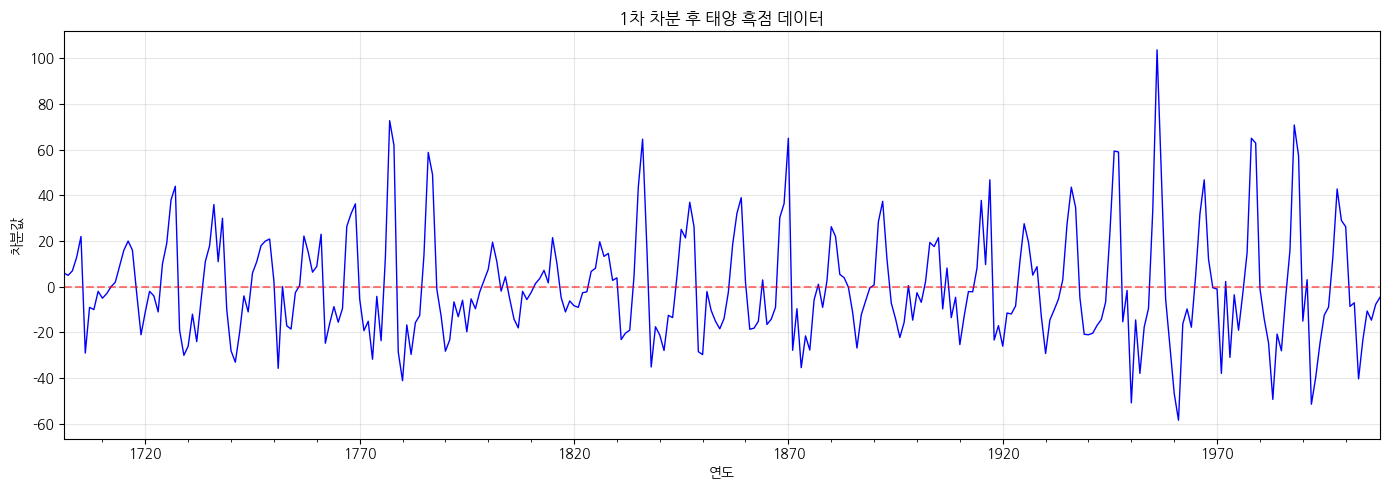

In [ ]:
# 1차 차분 적용
# 힌트: 차분 계산 후 결측치 제거
ts_diff = data['SUNACTIVITY'].****().******()

print(f"원본 데이터 개수: {len(data)}개")
print(f"1차 차분 후 데이터 개수: {len(ts_diff)}개")
print(f"\n1차 차분 기본 통계:")
print(ts_diff.describe())

# 시각화
plt.figure(figsize=(14, 5))
ts_diff.plot(title='1차 차분 후 태양 흑점 데이터', color='blue', linewidth=1)
plt.ylabel('차분값')
plt.xlabel('연도')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.1.1 1차 차분 데이터 정상성 검정

In [19]:
# 1차 차분 데이터에 대한 ADF 검정
print("="*50)
print("1차 차분 데이터 ADF 검정")
print("="*50)
is_stationary_adf_diff = adfuller_test(ts_diff)

print("\n" + "="*50)
print("1차 차분 데이터 KPSS 검정")
print("="*50)
is_stationary_kpss_diff = kpss_test(ts_diff)

1차 차분 데이터 ADF 검정
ADF Statistic: -14.86166
p-value: 0.0000
Lags: 7
Number of Observations: 300
검증결과: 정상(stationary) 시계열 데이터입니다.

1차 차분 데이터 KPSS 검정
KPSS Statistic: 0.02119
p-value: 0.1000
Lags: 0
검증결과: 정상(stationary) 시계열 데이터입니다.


C:\Temp\ipykernel_11696\1658052247.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stats, p_value, nlags, critical_values = kpss(series, **kw)


### 6.1.2 해석

**ADF/KPSS 검정 결과:**
- 1차 차분 후 ADF 검정은 정상성을 확인 (p-value < 0.05)
- KPSS 검정도 정상성을 확인 (p-value > 0.05)

**결론:** 1차 차분만으로도 통계적 검정상 정상성이 확보되었습니다.

# 후반부 실습
## 🌞 태양 흑점 데이터 시계열 모델 비교 실습

> **목표**: 다양한 시계열 분석 모델을 흑점 데이터에 적용하고, 각 모델의 적합성을 평가합니다.

**학습 목표:**
1. ACF & PACF로 데이터 특성 확인
2. 다양한 시계열 모델 (ARIMA, SARIMA, Exponential Smoothing, 단순 모델 등) 적용
3. 각 모델의 예측 성능 비교 및 적합성 평가
4. 데이터 특성에 맞는 최적 모델 선정

---
## 1. ACF & PACF로 데이터 특성 확인

**ACF (자기상관함수)**: 시계열 데이터가 과거 값들과 얼마나 상관있는지 측정  
**PACF (부분자기상관함수)**: 중간 시차의 영향을 제거한 직접적인 상관관계

**주요 함수:**
- `plot_acf()`: ACF 그래프 생성
- `plot_pacf()`: PACF 그래프 생성
- `lags`: 분석할 시차의 개수, 이 코드에서는 모두 20으로 설정!
- `ax`: 그래프를 그릴 subplot 축 지정

### 1.1 원본 데이터의 ACF & PACF

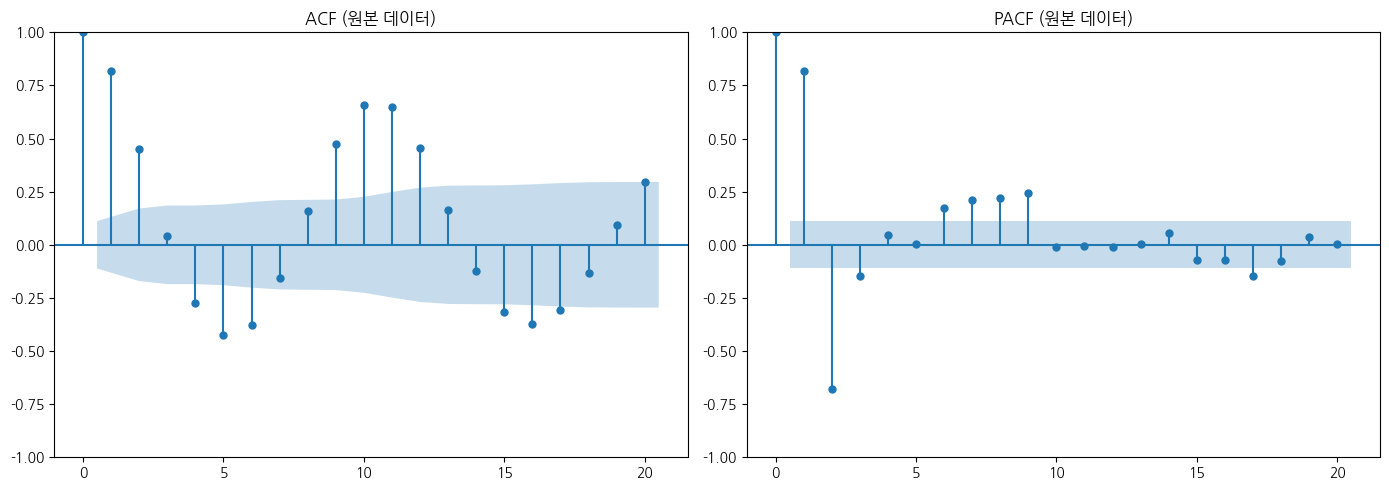

In [ ]:
# ACF & PACF 그래프 (원본 데이터)
# 힌트: plt.subplots(행, 열, figsize=(너비, 높이))
fig, axes = plt.********(1, 2, figsize=(14, 5))

# ACF
# 힌트: plot_acf(데이터, ax=축, lags=시차개수), 시차 개수는 20으로 통일
****_***(data['SUNACTIVITY'], ax=axes[0], lags=20)
axes[0].set_title("ACF (원본 데이터)")

# PACF
# 힌트: plot_pacf(데이터, ax=축, lags=시차개수)
****_****(data['SUNACTIVITY'], ax=axes[1], lags=**)
axes[1].set_title("PACF (원본 데이터)")

plt.tight_layout()
plt.show()

#### ACF & PACF 해석 (원본 데이터)

| 구분 | 관찰된 패턴 | 해석 |
|------|-------------|------|
| **ACF** | - Lag 1, 2, 9, 10, 11에서 강한 양(+) 상관<br>- 느리게 감소하며 반복 패턴<br>- 11년 주기로 톱니 모양 | → **비정상성(non-stationary)**<br>→ **주기성(seasonality)** 존재 |
| **PACF** | - Lag 1, 2에서 유의미한 변화<br>- Lag 9~11 부근에서 또 패턴 발생<br>- AR 구조 흔적 존재 | → **AR 구조 + 주기성 공존**<br>→ 원본 데이터를 그대로 ARIMA에 적용하기 어려움 |
| **종합 결론** | - 두 그래프 모두 강한 자기상관 + 반복 패턴 | → **원본 시계열은 바로 ARIMA 적용 불가**<br>→ **1차 차분(d=1) 또는 Seasonal ARIMA 필요** |

### 1.1.2 차분 후 데이터의 ACF & PACF

차분을 통해 정상성을 확보한 데이터의 자기상관 구조를 확인합니다.

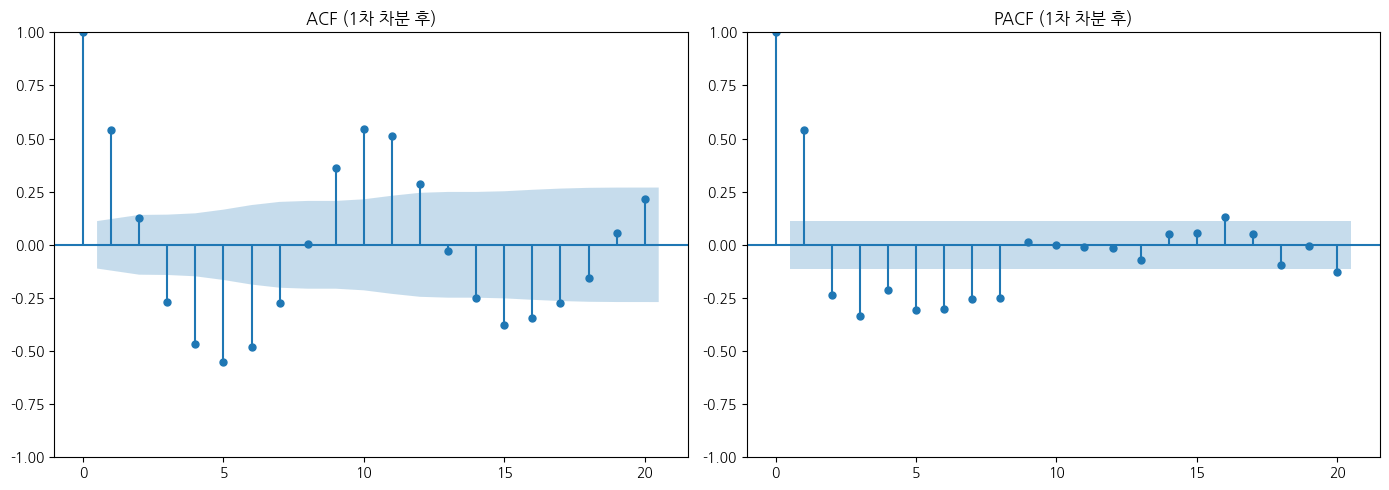

In [ ]:
# 1차 차분 후 acf pacf 그래프
data_diff = ts_diff.to_frame('SUNACTIVITY_diff')

# ACF & PACF 그래프 (1차 차분 후)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF 그래프
# 힌트: plot_acf(데이터, ax=축, lags=시차개수)
****_***(data_diff['SUNACTIVITY_diff'], ax=axes[0], lags=20)
axes[0].set_title("ACF (1차 차분 후)")

# PACF 그래프
# 힌트: plot_pacf(데이터, ax=축, lags=시차개수)
****_****(data_diff['SUNACTIVITY_diff'], ax=axes[1], lags=20)
axes[1].set_title("PACF (1차 차분 후)")

plt.tight_layout()
plt.show()

#### ACF & PACF 해석 (1차 차분 후)

| 구분 | 관찰된 패턴 | 해석 |
|------|-------------|------|
| **ACF (차분 후)** | Lag 9~11 부근에서 신뢰구간 밖의 양의 상관이 관찰됨 | → 태양 흑점 데이터의 약 11년 주기 구조가 일부 남아 있을 가능성이 있음 |
| **PACF (차분 후)** | 여러 lag에서 신뢰구간 밖의 값이 관찰됨 | → 차분 후에도 단순한 AR/MA 구조로 설명하기 어려운 자기상관이 남아 있음 |
| **종합 결론** | 1차 차분 후 정상성은 확보되었지만 일부 자기상관 구조가 남아 있음 | → 이후 모델링에서 11년 주기 구조를 반영할 수 있는 SARIMA를 사용해볼 수 있음 |


### 1.2 Train/Test 데이터 분할

모델 성능을 평가하기 위해 데이터를 훈련 세트와 테스트 세트로 분할합니다.
- **Train**: 1700~1980년 (약 90%)
- **Test**: 1981~2008년 (약 10%, 28년)

Train 기간: 1700 ~ 1980 (281개)
Test 기간: 1981 ~ 2008 (28개)
✅ Train freq: <YearBegin: month=1>, Test freq: <YearBegin: month=1>


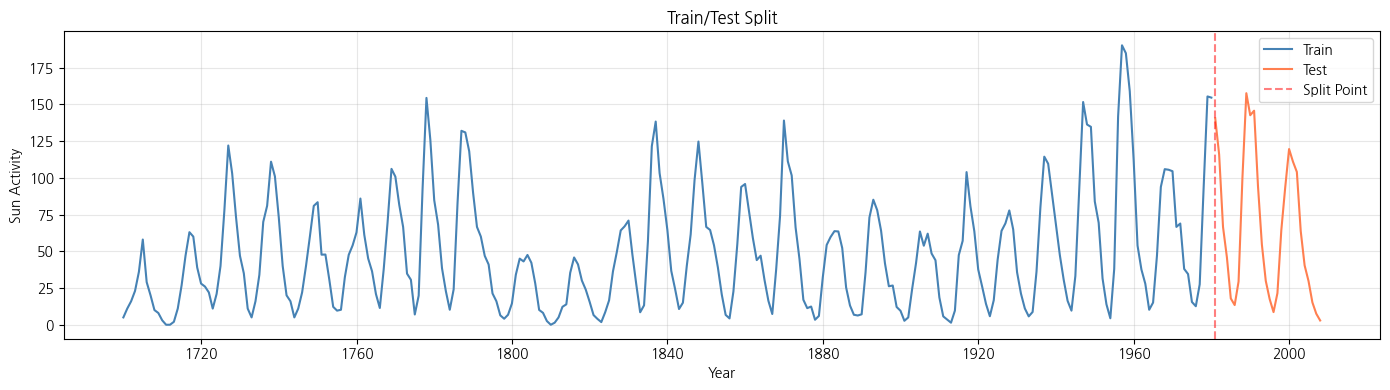

In [24]:
split_year = '1981-01-01'

train = data.loc[:split_year].iloc[:-1]
test = data.loc[split_year:]

# ✅ train/test에도 주파수 설정
train = train.asfreq('YS')
test = test.asfreq('YS')

print(f"Train 기간: {train.index[0].year} ~ {train.index[-1].year} ({len(train)}개)")
print(f"Test 기간: {test.index[0].year} ~ {test.index[-1].year} ({len(test)}개)")
print(f"✅ Train freq: {train.index.freq}, Test freq: {test.index.freq}")

# 시각화
plt.figure(figsize=(14, 4))
plt.plot(train.index, train['SUNACTIVITY'], label='Train', color='steelblue')
plt.plot(test.index, test['SUNACTIVITY'], label='Test', color='coral')
plt.axvline(test.index[0], color='red', linestyle='--', alpha=0.5, label='Split Point')
plt.title('Train/Test Split')
plt.xlabel('Year')
plt.ylabel('Sun Activity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 평가 지표 함수 정의

모델 성능을 정량적으로 비교하기 위한 함수를 정의합니다.

In [25]:
def evaluate_model(actual, predicted, model_name):
    """
    모델 예측 성능을 평가하는 함수

    Parameters:
    - actual: 실제값
    - predicted: 예측값
    - model_name: 모델 이름
    """
    # NaN 체크 및 제거
    mask = ~(pd.isna(actual) | pd.isna(predicted))
    actual_clean = actual[mask]
    predicted_clean = predicted[mask]

    if len(actual_clean) == 0:
        print(f"\n{'='*50}")
        print(f"⚠️ 모델: {model_name}")
        print(f"{'='*50}")
        print("❌ 모든 예측값이 NaN입니다. 모델 학습 실패!")
        print(f"{'='*50}")
        return {'model': model_name, 'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan, 'MAPE': np.nan}

    if len(actual_clean) < len(actual):
        nan_count = len(actual) - len(actual_clean)
        print(f"\n⚠️ {model_name}: {nan_count}개 NaN 값이 제거되었습니다.")

    mse = mean_squared_error(actual_clean, predicted_clean)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual_clean, predicted_clean)
    mape = np.mean(np.abs((actual_clean - predicted_clean) / actual_clean)) * 100

    print(f"\n{'='*50}")
    print(f"모델: {model_name}")
    print(f"{'='*50}")
    print(f"유효 데이터 포인트: {len(actual_clean)}/{len(actual)}")
    print(f"MSE  (Mean Squared Error):      {mse:.2f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"MAE  (Mean Absolute Error):     {mae:.2f}")
    print(f"MAPE (Mean Absolute % Error):   {mape:.2f}%")

    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# 결과를 저장할 리스트
results = []

---

## 2. 모델 1: Naive Forecast (기준 모델)

### 개념 소개

**Naive Forecast**는 가장 단순한 예측 방법으로, "다음 값은 현재 값과 같을 것"이라고 가정합니다.

$$\hat{y}_{t+1} = y_t$$

- **장점**: 구현이 매우 간단, 계산 비용 없음
- **단점**: 추세나 계절성을 전혀 고려하지 못함
- **용도**: 다른 모델의 성능을 비교하기 위한 **기준선(Baseline)**으로 사용

In [26]:
# Naive Forecast: 이전 값을 그대로 예측값으로 사용
naive_pred = test['SUNACTIVITY'].shift(1).fillna(train['SUNACTIVITY'].iloc[-1])

# 평가
result = evaluate_model(test['SUNACTIVITY'], naive_pred, 'Naive Forecast')
results.append(result)


모델: Naive Forecast
유효 데이터 포인트: 28/28
MSE  (Mean Squared Error):      876.82
RMSE (Root Mean Squared Error): 29.61
MAE  (Mean Absolute Error):     23.87
MAPE (Mean Absolute % Error):   57.38%


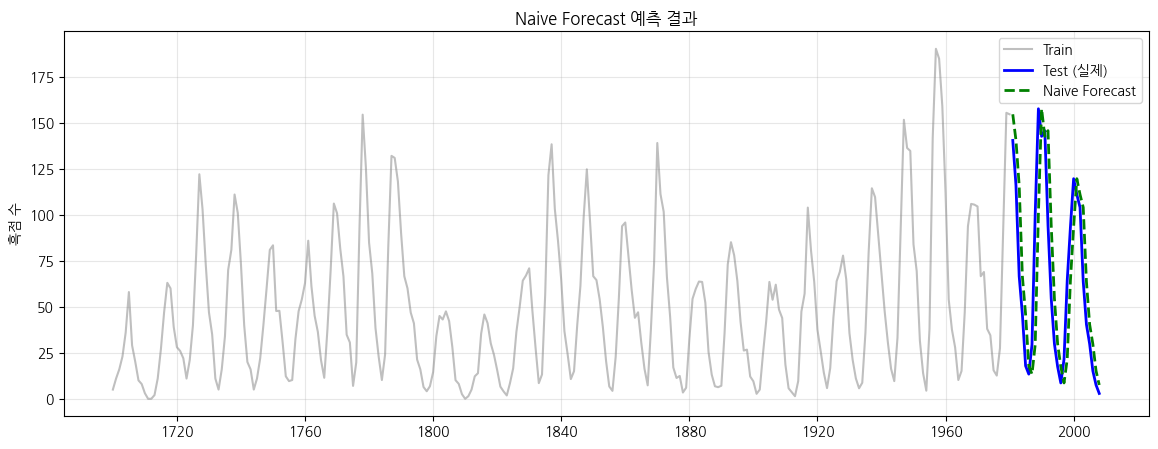

In [27]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['SUNACTIVITY'], label='Train', color='gray', alpha=0.5)
plt.plot(test.index, test['SUNACTIVITY'], label='Test (실제)', color='blue', linewidth=2)
plt.plot(test.index, naive_pred, label='Naive Forecast', color='green', linestyle='--', linewidth=2)
plt.title('Naive Forecast 예측 결과')
plt.ylabel('흑점 수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 결과 해석

- Naive 모델은 단순히 이전 시점의 값을 예측값으로 사용하므로, **1시점 뒤쳐진 패턴**을 보입니다.
- 급격한 변화가 있는 구간에서 예측 오차가 크게 발생합니다.
- 이 결과는 다른 모델들의 성능을 평가하기 위한 **기준선**으로 활용됩니다.

## 3. 모델링 방향 설정

태양 흑점 데이터는 약 11년 주기의 **반복적 변동**과 **자기상관 구조**를 가지므로, 단순 선형회귀나 단순 이동평균만으로는 주요 패턴을 충분히 설명하기 어렵습니다.  

따라서 이번 실습에서는 시계열의 차분 구조와 자기상관을 반영할 수 있는 **ARIMA**, 그리고 주기 구조까지 고려할 수 있는 **SARIMA**를 중심으로 예측 모델을 구성합니다.

---

## 4. 모델 2: ARIMA

### 개념 소개

**ARIMA (AutoRegressive Integrated Moving Average)**는 시계열 예측의 대표적인 모델입니다.

- **AR (p)**: 과거 p개 시점의 값으로 현재 값 예측 (자기회귀)
- **I (d)**: 차분 횟수 (정상성 확보)
- **MA (q)**: 과거 q개 시점의 오차항으로 현재 값 예측

**파라미터 선택:**
- 앞부분 실습에서 1차 차분으로 정상성을 확보했으므로 **d=1**
- ACF/PACF 그래프를 참고하여 **p=2, q=2** 선택 (실험적으로 조정 가능)

#### 이 데이터에 적합한가?

ARIMA는 자기상관 구조를 포착할 수 있어 **어느 정도 적합**하지만, **계절성(약 11년 주기의 반복적 변동)을 명시적으로 다루지 못하는 한계**가 있습니다.

In [ ]:
# ARIMA 모델 (p, d, q) = (2, 1, 2)
arima_order = (2, 1, 2)

print(f"ARIMA 모델 학습 중... order={arima_order}")

# 힌트: ARIMA(train['열이름'], order=파라미터)
arima_model = *****(train['SUNACTIVITY'], order=arima_order)

# 모델 학습
# 힌트: 모델객체.fit()
arima_fit = *****_*****.***()

print("\n모델 요약:")
print(arima_fit.summary())

ARIMA 모델 학습 중... order=(2, 1, 2)

모델 요약:
                               SARIMAX Results                                
Dep. Variable:            SUNACTIVITY   No. Observations:                  281
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1166.382
Date:                Sat, 23 May 2026   AIC                           2342.764
Time:                        00:12:21   BIC                           2360.938
Sample:                    01-01-1700   HQIC                          2350.053
                         - 01-01-1980                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5997      0.032     50.585      0.000       1.538       1.662
ar.L2         -0.9297      0.028    -33.627      0.000      -0.984      -0.876
ma.L1      

### 위 셀에서 `arima_order` 값을 바꿔가며 모델 결과를 비교해보세요!

**💡 파라미터 선택 가이드:**
- **p (AR 차수)**:  PACF가 신뢰구간 안으로 들어가기 시작하는 절단 시점을 참고
- **d (차분 차수)**: ADF 검정으로 정상성 확보에 필요한 차분 횟수
- **q (MA 차수)**:  ACF가 신뢰구간 안으로 들어가기 시작하는 절단 시점을 참고
- **모델 평가**: AIC, BIC가 낮을수록 좋음 (단, 과적합 주의)

In [ ]:
# 예측 수행
# 힌트: 학습된모델.forecast(steps=예측개수)
arima_predictions = *****_***.forecast(steps=len(test))
print(f"\n디버깅 - 예측값 중 NaN 개수: {pd.isna(arima_predictions).sum()}/{len(arima_predictions)}")

# 예측값을 Series로 변환하고 테스트 인덱스 할당
# 힌트: pd.Series(예측값, index=test.index)
arima_predictions = pd.Series(*****_***********, index=test.index)

# 평가
result = evaluate_model(test['SUNACTIVITY'], arima_predictions, f'ARIMA{arima_order}')
results.append(result)


디버깅 - 예측값 중 NaN 개수: 0/28

모델: ARIMA(2, 1, 2)
유효 데이터 포인트: 28/28
MSE  (Mean Squared Error):      531.97
RMSE (Root Mean Squared Error): 23.06
MAE  (Mean Absolute Error):     19.09
MAPE (Mean Absolute % Error):   134.85%


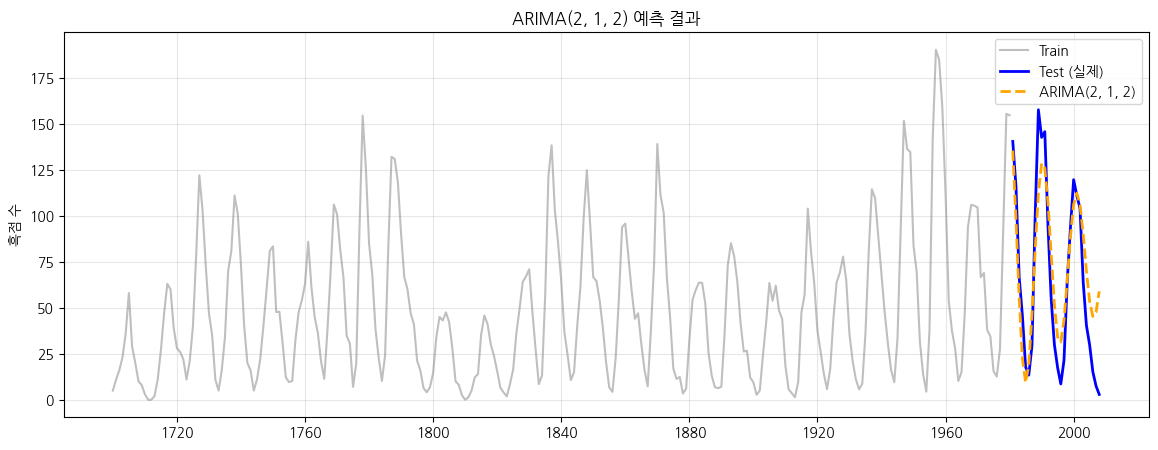

In [30]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['SUNACTIVITY'], label='Train', color='gray', alpha=0.5)
plt.plot(test.index, test['SUNACTIVITY'], label='Test (실제)', color='blue', linewidth=2)
plt.plot(test.index, arima_predictions, label=f'ARIMA{arima_order}', color='orange', linestyle='--', linewidth=2)
plt.title(f'ARIMA{arima_order} 예측 결과')
plt.ylabel('흑점 수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 결과 해석

- ARIMA는 1차 차분을 통해 비정상성을 완화한 뒤, 과거 값과 과거 예측 오차를 이용해 시계열의 자기상관 구조를 반영합니다.
- 다만, 약 11년 주기의 반복적 변동을 별도의 계절 항으로 명시적으로 반영하지는 못합니다.
- 따라서 다음 단계에서는 11년 주기 구조를 반영할 수 있는 SARIMA 모델을 적용하고, ARIMA와 예측 성능을 비교해보겠습니다.

---

## 5. 모델 3: SARIMA (계절성 고려)

### 개념 소개

**SARIMA (Seasonal ARIMA)**는 ARIMA에 계절성 요소를 추가한 모델입니다.

- **ARIMA(p, d, q)**: 비계절 요소
- **× (P, D, Q, s)**: 계절 요소
  - P: 계절 자기회귀 차수
  - D: 계절 차분 차수
  - Q: 계절 이동평균 차수
  - s: 계절 주기 (흑점 데이터는 약 11년)

**주요 함수/메서드:**
- `SARIMAX()`: SARIMA 모델 객체 생성
- `order`: (p, d, q) - 비계절 ARIMA 파라미터
- `seasonal_order`: (p, d, q)(P, D, Q, s) - 계절 파라미터
  - `P`: 계절 자기회귀(SAR) 차수
  - `D`: 계절 차분 차수
  - `Q`: 계절 이동평균(SMA) 차수
  - `s`: 계절 주기 (예: 11년)
- `enforce_stationarity`: 정상성 강제 여부
- `enforce_invertibility`: 가역성 강제 여부
- `fit()`: 모델 학습
  - `disp`: 학습 과정 출력 여부
  - `maxiter`: 최대 반복 횟수


**파라미터 선택:**
- 비계절: ARIMA(2, 1, 2)
- 계절: (1, 0, 1, 11) - 11년 주기 반영

#### 이 데이터에 적합한가?
SARIMA는 태양 흑점 데이터의 약 11년 주기적 변동을 모델에 반영할 수 있으므로, ARIMA와 비교해볼 만한 후보 모델입니다.  
다만 실제로 더 좋은 성능을 보이는지는 예측 결과와 평가 지표를 통해 확인해야 합니다.

In [ ]:
# SARIMA 모델 ARIMA(2,1,2) × (1,0,1,11)
sarima_order = (2, 1, 2)
sarima_seasonal = (1, 0, 1, 11)

print(f"SARIMA 모델 학습 중... order={sarima_order}, seasonal_order={sarima_seasonal}")
print("⚠️ 계절 주기가 11이므로 학습에 시간이 걸릴 수 있습니다...")

# SARIMA 모델 생성
# 힌트: SARIMAX(train['열이름'], order=비계절파라미터, seasonal_order=계절파라미터)
sarima_model = *******(
    train['SUNACTIVITY'],
    order=sarima_order,
    seasonal_order=sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=True, maxiter=200)

print("\n모델 요약:")
print(sarima_fit.summary())

SARIMA 모델 학습 중... order=(2, 1, 2), seasonal_order=(1, 0, 1, 11)
⚠️ 계절 주기가 11이므로 학습에 시간이 걸릴 수 있습니다...

모델 요약:
                                      SARIMAX Results                                       
Dep. Variable:                          SUNACTIVITY   No. Observations:                  281
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 11)   Log Likelihood               -1108.316
Date:                              Sat, 23 May 2026   AIC                           2230.631
Time:                                      00:31:39   BIC                           2255.716
Sample:                                  01-01-1700   HQIC                          2240.709
                                       - 01-01-1980                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [32]:
# 예측
sarima_predictions = sarima_fit.forecast(steps=len(test))
print(f"\n디버깅 - 예측값 중 NaN 개수: {pd.isna(sarima_predictions).sum()}/{len(sarima_predictions)}")
sarima_predictions = pd.Series(sarima_predictions, index=test.index)

# 평가
result = evaluate_model(test['SUNACTIVITY'], sarima_predictions, f'SARIMA{sarima_order}×{sarima_seasonal}')
results.append(result)


디버깅 - 예측값 중 NaN 개수: 0/28

모델: SARIMA(2, 1, 2)×(1, 0, 1, 11)
유효 데이터 포인트: 28/28
MSE  (Mean Squared Error):      615.36
RMSE (Root Mean Squared Error): 24.81
MAE  (Mean Absolute Error):     20.52
MAPE (Mean Absolute % Error):   149.43%


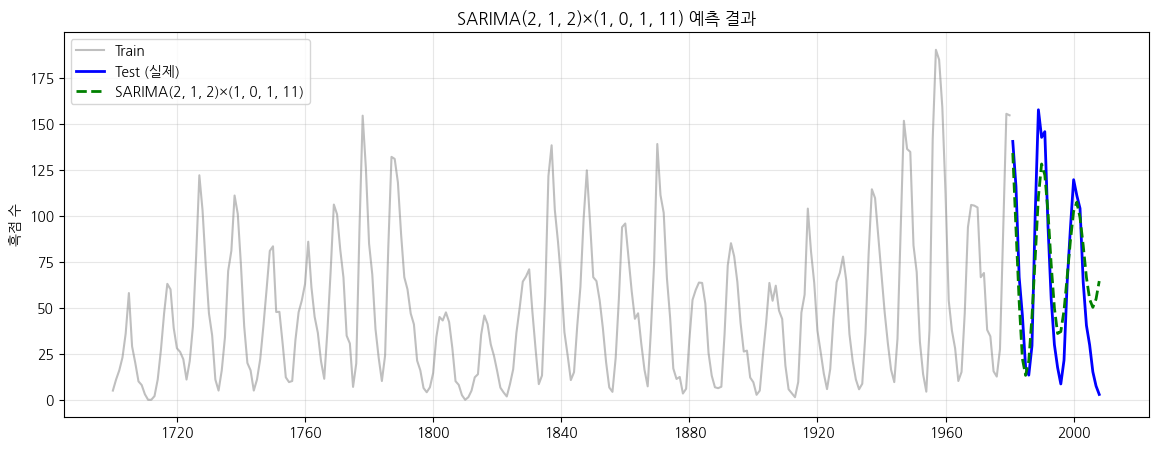

In [33]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['SUNACTIVITY'], label='Train', color='gray', alpha=0.5)
plt.plot(test.index, test['SUNACTIVITY'], label='Test (실제)', color='blue', linewidth=2)
plt.plot(test.index, sarima_predictions, label=f'SARIMA{sarima_order}×{sarima_seasonal}', color='green', linestyle='--', linewidth=2)
plt.title(f'SARIMA{sarima_order}×{sarima_seasonal} 예측 결과')
plt.ylabel('흑점 수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 결과 해석

- SARIMA는 ARIMA에 계절/주기 항을 추가하여, 태양 흑점 데이터의 약 11년 반복적 변동을 모델에 반영할 수 있습니다.
- 이번 실습에서는 별도의 계절 차분은 적용하지 않고(`D=0`), 11년 주기를 계절 AR/MA 항으로 반영했습니다.
- 실제 성능은 ARIMA와 SARIMA의 RMSE, MAE를 비교하여 판단합니다.

---

## 7. 모델 4: Exponential Smoothing (Holt-Winters)

### 개념 소개

**Exponential Smoothing(지수평활법)**은 과거 관측값에 가중치를 부여해 시계열의 흐름을 예측하는 방법입니다.  
일반적으로 최근 관측값에 더 큰 가중치를 두어, 최신 변화가 예측에 더 많이 반영되도록 합니다.

**Holt-Winters 방법**은 세 가지 요소를 평활화합니다:
- **Level (수준)**: 데이터의 평균 수준
- **Trend (추세)**: 데이터의 증가/감소 경향
- **Seasonal (계절성)**: 주기적 패턴

**파라미터:**
- `seasonal='add'` 또는 `'mul'`: 가법/승법 계절성
- `seasonal_periods=11`: 약 11년 주기 설정

#### 이 데이터에 적합한가?

Holt-Winters는 추세와 반복적 주기 성분을 함께 다룰 수 있으므로, 약 11년 주기를 보이는 태양 흑점 데이터에 적용해볼 수 있습니다.  
다만 태양 흑점 데이터는 주기의 진폭과 길이가 완전히 일정하지 않기 때문에, Holt-Winters가 항상 가장 좋은 성능을 보인다고 단정할 수는 없습니다. 실제 적합성은 ARIMA, SARIMA와의 예측 성능 비교를 통해 확인합니다.

In [ ]:
# Exponential Smoothing (Holt-Winters)
# 가법 모델 사용 (seasonal='add')
seasonal_periods = 11

print(f"Holt-Winters 모델 학습 중... seasonal_periods={seasonal_periods}")

# Holt-Winters 모델 생성
# 힌트: ExponentialSmoothing(train['열이름'], seasonal='타입', seasonal_periods=주기, trend='타입')
hw_model = ********************(
    train['SUNACTIVITY'],
    seasonal='add',
    seasonal_periods=11,
    trend='add',
)

# 모델 학습 (파라미터 자동 최적화)
# 힌트: 모델객체.fit(optimized=True, use_brute=False)
hw_fit = **_*****.fit(optimized=True, use_brute=False)

Holt-Winters 모델 학습 중... seasonal_periods=11


In [35]:
# 예측
hw_predictions = hw_fit.forecast(steps=len(test))
print(f"\n디버깅 - 예측값 중 NaN 개수: {pd.isna(hw_predictions).sum()}/{len(hw_predictions)}")
hw_predictions = pd.Series(hw_predictions, index=test.index)

# 평가
result = evaluate_model(test['SUNACTIVITY'], hw_predictions, 'Holt-Winters (Exponential Smoothing)')
results.append(result)


디버깅 - 예측값 중 NaN 개수: 0/28

모델: Holt-Winters (Exponential Smoothing)
유효 데이터 포인트: 28/28
MSE  (Mean Squared Error):      5426.44
RMSE (Root Mean Squared Error): 73.66
MAE  (Mean Absolute Error):     63.36
MAPE (Mean Absolute % Error):   393.24%


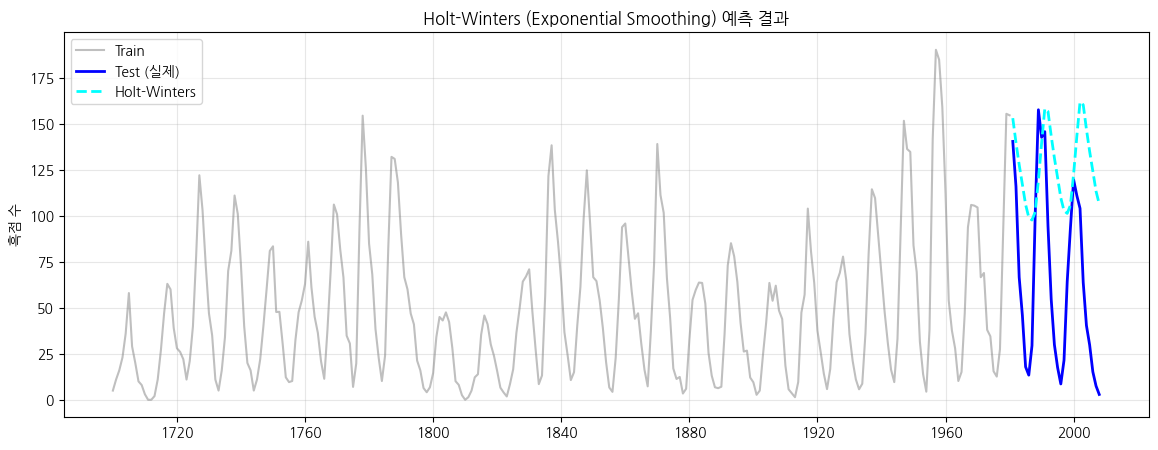

In [36]:
# 시각화
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['SUNACTIVITY'], label='Train', color='gray', alpha=0.5)
plt.plot(test.index, test['SUNACTIVITY'], label='Test (실제)', color='blue', linewidth=2)
plt.plot(test.index, hw_predictions, label='Holt-Winters', color='cyan', linestyle='--', linewidth=2)
plt.title('Holt-Winters (Exponential Smoothing) 예측 결과')
plt.ylabel('흑점 수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 결과 해석

- Holt-Winters는 수준, 추세, 반복적 주기 성분을 함께 반영하는 모델
- 그러나 이번 실습에서는 RMSE 73.66으로 ARIMA/SARIMA보다 큰 예측 오차를 보였음
- 이는 태양 흑점 데이터가 약 11년 주기를 보이더라도, 각 주기의 길이와 진폭이 일정하지 않기 때문으로 해석할 수 있음
- 즉, 과거에서 학습한 평균적인 주기 패턴이 Test 구간의 실제 peak와 valley를 충분히 따라가지 못한 것으로 볼 수 있음
- 따라서 Holt-Winters처럼 비교적 고정적인 추세·주기 패턴을 가정하는 모델은, 불규칙한 주기 변동이 큰 데이터에서는 예측 성능이 낮아질 수 있음

---

## 8. 모델 성능 비교

모든 모델의 성능을 한눈에 비교해봅시다.

In [37]:
# 결과를 DataFrame으로 정리
results_df = pd.DataFrame(results)

# RMSE 기준으로 정렬
results_df = results_df.sort_values('RMSE')

print("\n" + "="*80)
print("모델 성능 비교 (RMSE 기준 오름차순)")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


모델 성능 비교 (RMSE 기준 오름차순)
                               model         MSE      RMSE       MAE       MAPE
                      ARIMA(2, 1, 2)  531.974030 23.064562 19.086445 134.849466
       SARIMA(2, 1, 2)×(1, 0, 1, 11)  615.359854 24.806448 20.516435 149.432168
                      Naive Forecast  876.824643 29.611225 23.867857  57.380883
Holt-Winters (Exponential Smoothing) 5426.441973 73.664387 63.362447 393.236022


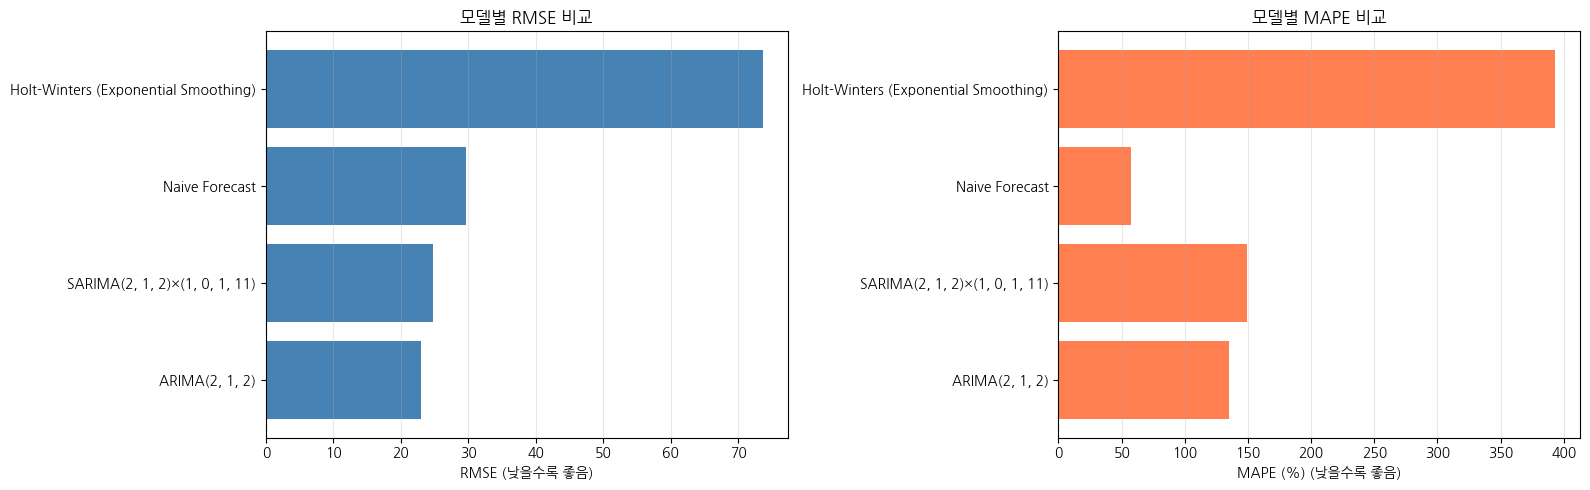

In [38]:
# 시각화: RMSE 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE 막대 그래프
axes[0].barh(results_df['model'], results_df['RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE (낮을수록 좋음)')
axes[0].set_title('모델별 RMSE 비교')
axes[0].grid(True, alpha=0.3, axis='x')

# MAPE 막대 그래프
axes[1].barh(results_df['model'], results_df['MAPE'], color='coral')
axes[1].set_xlabel('MAPE (%) (낮을수록 좋음)')
axes[1].set_title('모델별 MAPE 비교')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---

## 9. 종합 결론 및 모델 적합성 평가

### 📊 실제 모델 성능 비교 (RMSE 기준)

| 순위 | 모델 | RMSE | MAPE (%) | 적합성 평가 |
|------|------|------|----------|-------------|
| 1위 🥇 | **ARIMA(2,1,2)** | **23.06** | 134.85 | ✅ 가장 우수 |
| 2위 🥈 | **SARIMA(2,1,2)×(1,0,1,11)** | **24.81** | 149.43 | ✅ 적합 |
| 3위 🥉 | **Naive Forecast** | **29.61** | **57.38** | △ 기준선 |
| 4위 | **Holt-Winters** | **73.66** | 393.24 | ❌ 이 데이터셋에서 부적합 |

*MAPE는 실제값이 0에 가깝거나 작은 경우 값이 크게 왜곡될 수 있으므로, 태양 흑점 데이터에서는 보조 지표로만 참고*

### 모델별 상세 평가

| 모델 | 적합성 | 이유 |
|------|--------|------|
| **ARIMA(2,1,2)** | ✅ 가장 적합 | - 이 데이터셋에서 최고 성능 (RMSE 23.06)<br>- 1차 차분과 자기상관 구조를 반영하여 안정적인 예측 성능을 보임<br>- SARIMA보다 단순한 구조임에도 더 낮은 오차를 기록함 |
| **SARIMA(2,1,2)×(1,0,1,11)** | ✅ 적합 | - ARIMA와 근소한 차이 (RMSE 24.81)<br>- 약 11년 주기 구조를 계절 AR/MA 항으로 반영<br>- 다른 seasonal_order 조합을 탐색하면 성능이 달라질 수 있음 |
| **Naive Forecast** | △ 기준선 | - ARIMA/SARIMA보다 RMSE는 높지만, MAPE는 가장 낮게 나타남<br>- 직전 값을 그대로 사용하는 단순 기준선 모델<br>- 복잡한 주기 구조는 반영하지 못하지만, 기준선으로 유용 |
| **Holt-Winters** | ❌ 이 설정에서 부적합 | - 가장 높은 RMSE (73.66)와 MAPE (393.32%)<br>- 다른 파라미터 설정을 시도할 수 있으나, 본 실습 설정에서는 성능이 낮게 나타남 |

### 💡 중요한 발견과 교훈

#### 1. 이론과 실제의 괴리
- **예상**: 약 11년 주기 구조를 반영하는 SARIMA가 가장 우수할 것으로 예상할 수 있음
- **실제**: ARIMA가 SARIMA보다 근소하게 낮은 RMSE를 보임
- **교훈**: 모델의 복잡도가 항상 성능 향상을 보장하지 않으며, 실제 데이터에서 검증 필수

#### 2. Holt-Winters는 왜 성능이 낮았을까?
- **현상**: Holt-Winters는 이번 설정에서 가장 큰 예측 오차를 보였습니다.
- **원인**: 태양 흑점 데이터는 약 11년 주기를 보이지만, 각 주기의 길이와 진폭이 완전히 일정하지 않습니다.
- Holt-Winters는 과거에서 학습한 평균적인 수준·추세·주기 패턴을 바탕으로 미래를 예측하므로, test 구간의 불규칙한 peak와 valley를 충분히 따라가지 못할 수 있습니다.
- **교훈**: 주기성이 존재한다고 해서 모든 주기 모델이 잘 맞는 것은 아니며, 데이터의 진폭 변화와 주기 불규칙성을 함께 확인해야 합니다.

#### 3. 평가지표의 함정: RMSE vs MAPE
- **현상**: RMSE 기준 1위는 ARIMA였지만, MAPE 기준으로는 Naive Forecast가 가장 낮게 나타났습니다.
- **원인**: MAPE는 실제값을 분모로 사용하므로, 실제 흑점 수가 0에 가까운 극소기에는 작은 예측 오차도 매우 큰 비율 오차로 계산될 수 있습니다.
- Naive Forecast는 직전 값을 그대로 사용하는 방식이므로, 값이 낮게 유지되는 구간에서는 상대적으로 낮은 MAPE가 나타날 수 있습니다.
- **교훈**: 0에 가까운 값이 포함된 데이터에서는 MAPE가 왜곡될 수 있으므로, RMSE·MAE와 함께 종합적으로 해석해야 합니다.